In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle


In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [9]:
z_list = [5, 4, 3, 2, 1.5,1,  0.4, 0.1, 0]

In [10]:
snap_list = [17, 21, 25,33, 40, 50, 72,91, 99]

In [12]:
def compute_intensity(mean_intensity, z):
    factor15 = compute_intensity_factor(z=1.5)
    
    factor_z = compute_intensity_factor(z=z)
    
    mean_intensity_z = mean_intensity * factor15/factor_z
    
    return mean_intensity_z
    

In [13]:

odir = "../ps_data"

ratio_list = []
intensity_list_group = []
intensity_list_cent = []

iend = 474

for i, snapnum in enumerate(snap_list):
    with open(f"{odir}/snap{snapnum}/mvir/ps-intensity-group_logM10.pickle", "rb") as f:
        Pk_mean_sum10 = pickle.load(f)
        Pk_sum10 = pickle.load(f)


    with open(f"{odir}/snap{snapnum}/mvir/ps-intensity-cent_logM10.pickle", "rb") as f:
        Pk_mean_cent10 = pickle.load(f)
        Pk_cent10 = pickle.load(f)
    
    k = Pk_cent10["k"][:iend]
    ratio = Pk_cent10["power"].real[:iend]/Pk_sum10["power"].real[:iend]
    
    ratio_list.append(ratio)
    
    intensity_group = compute_intensity(Pk_mean_sum10, z_list[i])
    
    intensity_cent = compute_intensity(Pk_mean_cent10, z_list[i])
    intensity_list_cent.append(intensity_cent)
    intensity_list_group.append(intensity_group)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in double_scalars
  from ipykernel import kernelapp as app
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:32: RuntimeWarning: invalid value encountered in double_scalars


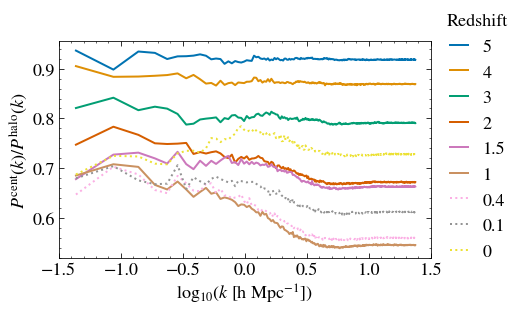

In [15]:
for i in range(0,6):
    plt.plot(np.log10(k), ratio_list[i], label=z_list[i], c=palette_tab10[i])
    
for i in range(6,9):
    plt.plot(np.log10(k), ratio_list[i], label=z_list[i], linestyle="dotted", c=palette_tab10[i])
    
plt.legend(loc="upper left", bbox_to_anchor=(1,1.2), title="Redshift", handlelength=1)
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h\ Mpc^{-1}]})$")
plt.ylabel("$P^{\mathrm{cent}}(k)/P^{\mathrm{halo}}(k)$")
plt.xlim(-1.5,1.5)
plt.savefig("../figures/cent_vs_halo_ps_z.pdf", format="pdf", bbox_inches="tight")